In [ ]:
import pandas as pd

To use a specific font like "Times New Roman", you typically need to:

1. **Download the font file:** You can often find `.ttf` (TrueType Font) or `.otf` (OpenType Font) files for fonts online. Make sure you have the necessary rights to use and download the font.
2. **Upload the font file to your Colab environment:** You can do this manually through the file explorer in the left sidebar of Colab.
3. **Install the font in the system (optional but recommended):** You can use shell commands to copy the font file to the system's font directory.
4. **Update matplotlib's font cache:** Matplotlib caches font information, so you need to clear and rebuild this cache after adding new fonts.

Here's an example of how you might do this using shell commands in a code cell, assuming you have uploaded a font file named `timesnewroman.ttf` to your Colab session:

In [ ]:
!wget https://github.com/misuchiru03/font-times-new-roman/raw/master/Times%20New%20Roman.ttf
!wget https://github.com/misuchiru03/font-times-new-roman/raw/master/Times%20New%20Roman%20-%20Bold.ttf

--2025-10-03 14:56:24--  https://github.com/misuchiru03/font-times-new-roman/raw/master/Times%20New%20Roman.ttf
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/misuchiru03/font-times-new-roman/master/Times%20New%20Roman.ttf [following]
--2025-10-03 14:56:24--  https://raw.githubusercontent.com/misuchiru03/font-times-new-roman/master/Times%20New%20Roman.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330412 (323K) [application/octet-stream]
Saving to: ‘Times New Roman.ttf.1’

Times New Roman.ttf 100%[===================>] 322.67K  --.-KB/s    in 0.03s   

2025-10-03 14:56:24 (9.38 MB/s) - ‘Ti

In [ ]:
# @title Install Times New Roman font (example)
# This is an example. Replace 'timesnewroman.ttf' with your actual font file name.
# You may need to adjust the destination directory based on the Colab environment.

!mkdir -p ~/.fonts
!cp '/content/Times New Roman - Bold.ttf' ~/.fonts/
!cp '/content/Times New Roman.ttf' ~/.fonts/

# Update the font cache
!fc-cache -fv

# Remove matplotlib's font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

print("Font installation steps completed. You might need to restart the runtime for changes to take full effect.")

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: caching, new cache contents: 2 fonts, 0 dirs
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
fc-cache: succeeded
Font installation steps completed. You might need to restart the runtime for changes to take full effect.


After running the above cell and potentially restarting your runtime (Runtime -> Restart runtime), you can verify if the font is available:

['Times New Roman', 'Times New Roman']


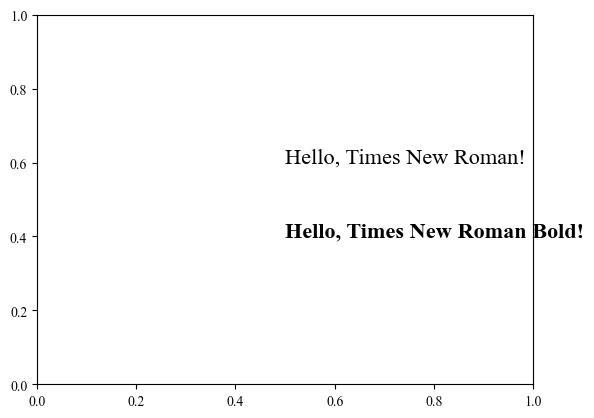

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# List all available fonts to check if 'Times New Roman' and 'Times New Roman - Bold' are now listed
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
print([fm.FontProperties(fname=fname).get_name() for fname in font_list if 'Times New Roman' in fm.FontProperties(fname=fname).get_name()])

# You can also try setting the font and plotting simple text to see if it works
plt.rcParams['font.family'] = 'Times New Roman'
plt.text(0.5, 0.6, 'Hello, Times New Roman!', fontdict={'family': 'Times New Roman', 'size': 16})
plt.text(0.5, 0.4, 'Hello, Times New Roman Bold!', fontdict={'family': 'Times New Roman', 'size': 16, 'weight': 'bold'})
plt.show()

Once you've confirmed the font is available, you can then use `plt.rcParams["font.family"] = "Times New Roman"` in your plotting code.

# Load all the datasets

## Task 1A

In [ ]:
github_link = "https://github.com/AridHasan/blp25_task1/blob/main/data/subtask_1A/"
raw_link = github_link.replace("blob/", "").replace("github.com", "raw.githubusercontent.com")

train_1A_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1A_train.tsv", sep="\t", keep_default_na=False)
dev_1A_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1A_dev.tsv", sep="\t", keep_default_na=False)
dev_test_1A_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1A_dev_test_with_labels.tsv", sep="\t", keep_default_na=False)
test_1A_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1A_test_with_labels.tsv", sep="\t", keep_default_na=False)

In [ ]:
train_1A_df

,id,text,label
0,147963,ধন্যবাদ বর্ডার গার্ড দেরকে এভাবে পাহারা দিতে হ...,None
1,214275,ছোটবেলায় অনেক কষ্ট করে কিছু গালাগালি শিখছিলাম...,None
2,849172,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,Abusive
3,821985,চিন ভারত রাশিয়া এই তিন দেশ এক থাকলে বিশ্বকে শা...,None
4,477288,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই ...,Abusive
...,...,...,...
35517,790325,তইওয়ানের এত ক্ষমতা হয়নি যে এক টুকরো জায়গা নষ্ট...,None
35518,328377,চুরের ঘরের চুর হালা,Profane
35519,69803,জাহাঙ্গীর বুদ্ধি নেই মাঠে মারা যাবে,Abusive
35520,419984,একটা ফেইল্ড এস্টেট এও সুষ্ঠু নির্বাচন হয় নেতার...,Abusive


In [ ]:
dev_1A_df

,id,text,label
0,166449,ইন্ডিয়া কি মাছ ধরা বন্ধ রাখছেএক নদীতে দুইনীতি ...,Political Hate
1,267692,লক্ষ টাকা ঘুষ দিয়ে অযোগ্য আর দায়িত্বহীন মানস...,Abusive
2,184031,ওহা ভবনের দালাল,None
3,939131,আর কতো শিখবে আমার সোনার ছেলেরা এগুলো কে টাকা দ...,Abusive
4,210284,কি সাংঘাতিক ভাই রে তুই,Abusive
...,...,...,...
2507,350971,পুরোনো ইতিহাস তুলে ধরার জন্য সময় সংবাদ কে ধন্...,None
2508,539053,এই জন্যই আমাদের মেয়েরা কোরিয়া চলে যেতে চায়,None
2509,200314,এই শালা ইবলিশ এর বস এবলিশ এদের দেখে ভয় পায়,Abusive
2510,788171,আমি কিনে ফেলছি আই ফোন ১৪,None


In [ ]:
dev_test_1A_df

,id,text,label
0,879187,শুভ কামনা রইল বাংলাদেশ জন্য ইনশাআল্লাহ জয় হবে,None
1,316919,গোয়া মারা দিয়ে আছে বাংলাদেশ মাদারচোদ নিউজ করে ...,Profane
2,916242,ভাইয়া আপনি অভিনেতা হইয়েন না না হলে সবাই বাচ্...,Abusive
3,786824,আমাদেরো তাই দেখছি,None
4,47284,পুলিশ কতটা টাকা নিয়ে,None
...,...,...,...
2507,776466,সত্য কথা তেতু লাগে,None
2508,849227,এই ফকিননি মাগীটা আর কত নাটক দেখাবে,Abusive
2509,532697,দেখো আজকে কার ফিটনেস কোথায় দাঁড়িয়েছে তুমি চ...,Profane
2510,861411,ছোট ভাইটির পাসে থাকুন গেম ভিড়িও বানাই,None


In [ ]:
test_1A_df

,id,text,label
0,12764,ইজরায়েলের বিচার হওয়া উচিৎ,Abusive
1,202933,শামীম ওসামা বিন হাসিনা,None
2,165894,হেন কাপ পুলিশের মারে অন্যরা তাহলে পলিশের কি হব...,None
3,124999,আল্লাহ্ এসব জানোয়ারদের শেষ করে দাও,Profane
4,535301,ইহুদির বাচ্চা ইহুদী ই হবে,Religious Hate
...,...,...,...
10195,908819,শালা জঙ্গি নিচু জাত বাংলাদেশের শালা নিজের দেশ ...,Profane
10196,597085,এরে হেতি হাগল অই গেছে হেতিরে পাবনা নে,Abusive
10197,901448,এখান থেকে প্রমান হলো বাংলার মীর জাফর চাইলেই তা...,None
10198,617821,শুনি যে এই দেশের সংবিধান গণতান্ত্রিক সংবিধান ক...,None


## Task 1B

In [ ]:
github_link = "https://github.com/AridHasan/blp25_task1/blob/main/data/subtask_1B/"
raw_link = github_link.replace("blob/", "").replace("github.com", "raw.githubusercontent.com")

train_1B_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1B_train.tsv", sep="\t", keep_default_na=False)
dev_1B_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1B_dev.tsv", sep="\t", keep_default_na=False)
dev_test_1B_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1B_dev_test_with_labels.tsv", sep="\t", keep_default_na=False)
test_1B_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1B_test_with_labels.tsv", sep="\t", keep_default_na=False)


In [ ]:
train_1B_df

,id,text,label
0,147963,ধন্যবাদ বর্ডার গার্ড দেরকে এভাবে পাহারা দিতে হ...,None
1,214275,ছোটবেলায় অনেক কষ্ট করে কিছু গালাগালি শিখছিলাম...,None
2,849172,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,Individual
3,821985,চিন ভারত রাশিয়া এই তিন দেশ এক থাকলে বিশ্বকে শা...,None
4,477288,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই ...,Individual
...,...,...,...
35517,790325,তইওয়ানের এত ক্ষমতা হয়নি যে এক টুকরো জায়গা নষ্ট...,None
35518,328377,চুরের ঘরের চুর হালা,None
35519,69803,জাহাঙ্গীর বুদ্ধি নেই মাঠে মারা যাবে,Individual
35520,419984,একটা ফেইল্ড এস্টেট এও সুষ্ঠু নির্বাচন হয় নেতার...,Organization


In [ ]:
dev_1B_df

,id,text,label
0,166449,ইন্ডিয়া কি মাছ ধরা বন্ধ রাখছেএক নদীতে দুইনীতি ...,Society
1,267692,লক্ষ টাকা ঘুষ দিয়ে অযোগ্য আর দায়িত্বহীন মানস...,Organization
2,184031,ওহা ভবনের দালাল,None
3,939131,আর কতো শিখবে আমার সোনার ছেলেরা এগুলো কে টাকা দ...,Individual
4,210284,কি সাংঘাতিক ভাই রে তুই,Individual
...,...,...,...
2507,350971,পুরোনো ইতিহাস তুলে ধরার জন্য সময় সংবাদ কে ধন্...,None
2508,539053,এই জন্যই আমাদের মেয়েরা কোরিয়া চলে যেতে চায়,None
2509,200314,এই শালা ইবলিশ এর বস এবলিশ এদের দেখে ভয় পায়,Individual
2510,788171,আমি কিনে ফেলছি আই ফোন ১৪,None


In [ ]:
dev_test_1B_df

,id,text,label
0,879187,শুভ কামনা রইল বাংলাদেশ জন্য ইনশাআল্লাহ জয় হবে,None
1,316919,গোয়া মারা দিয়ে আছে বাংলাদেশ মাদারচোদ নিউজ করে ...,Organization
2,916242,ভাইয়া আপনি অভিনেতা হইয়েন না না হলে সবাই বাচ্...,Individual
3,786824,আমাদেরো তাই দেখছি,None
4,47284,পুলিশ কতটা টাকা নিয়ে,None
...,...,...,...
2507,776466,সত্য কথা তেতু লাগে,None
2508,849227,এই ফকিননি মাগীটা আর কত নাটক দেখাবে,Individual
2509,532697,দেখো আজকে কার ফিটনেস কোথায় দাঁড়িয়েছে তুমি চ...,Individual
2510,861411,ছোট ভাইটির পাসে থাকুন গেম ভিড়িও বানাই,None


In [ ]:
test_1B_df

,id,text,label
0,12764,ইজরায়েলের বিচার হওয়া উচিৎ,Society
1,202933,শামীম ওসামা বিন হাসিনা,None
2,165894,হেন কাপ পুলিশের মারে অন্যরা তাহলে পলিশের কি হব...,None
3,124999,আল্লাহ্ এসব জানোয়ারদের শেষ করে দাও,Community
4,535301,ইহুদির বাচ্চা ইহুদী ই হবে,Community
...,...,...,...
10195,908819,শালা জঙ্গি নিচু জাত বাংলাদেশের শালা নিজের দেশ ...,Individual
10196,597085,এরে হেতি হাগল অই গেছে হেতিরে পাবনা নে,Individual
10197,901448,এখান থেকে প্রমান হলো বাংলার মীর জাফর চাইলেই তা...,None
10198,617821,শুনি যে এই দেশের সংবিধান গণতান্ত্রিক সংবিধান ক...,None


## Task 1C

In [ ]:
github_link = "https://github.com/AridHasan/blp25_task1/blob/main/data/subtask_1C/"
raw_link = github_link.replace("blob/", "").replace("github.com", "raw.githubusercontent.com")

train_1C_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1C_train.tsv", sep="\t", keep_default_na=False)
dev_1C_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1C_dev.tsv", sep="\t", keep_default_na=False)
dev_test_1C_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1C_dev_test_with_labels.tsv", sep="\t", keep_default_na=False)
test_1C_df = pd.read_csv(raw_link+"blp25_hatespeech_subtask_1C_test_with_labels.tsv", sep="\t", keep_default_na=False)

In [ ]:
train_1C_df

,id,text,hate_type,hate_severity,to_whom
0,147963,ধন্যবাদ বর্ডার গার্ড দেরকে এভাবে পাহারা দিতে হ...,None,Little to None,None
1,214275,ছোটবেলায় অনেক কষ্ট করে কিছু গালাগালি শিখছিলাম...,None,Little to None,None
2,849172,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,Abusive,Little to None,Individual
3,821985,চিন ভারত রাশিয়া এই তিন দেশ এক থাকলে বিশ্বকে শা...,None,Little to None,None
4,477288,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই ...,Abusive,Severe,Individual
...,...,...,...,...,...
35517,790325,তইওয়ানের এত ক্ষমতা হয়নি যে এক টুকরো জায়গা নষ্ট...,None,Little to None,None
35518,328377,চুরের ঘরের চুর হালা,Profane,Mild,None
35519,69803,জাহাঙ্গীর বুদ্ধি নেই মাঠে মারা যাবে,Abusive,Mild,Individual
35520,419984,একটা ফেইল্ড এস্টেট এও সুষ্ঠু নির্বাচন হয় নেতার...,Abusive,Mild,Organization


In [ ]:
dev_1C_df

,id,text,hate_type,hate_severity,to_whom
0,166449,ইন্ডিয়া কি মাছ ধরা বন্ধ রাখছেএক নদীতে দুইনীতি ...,Political Hate,Mild,Society
1,267692,লক্ষ টাকা ঘুষ দিয়ে অযোগ্য আর দায়িত্বহীন মানস...,Abusive,Little to None,Organization
2,184031,ওহা ভবনের দালাল,None,Little to None,None
3,939131,আর কতো শিখবে আমার সোনার ছেলেরা এগুলো কে টাকা দ...,Abusive,Mild,Individual
4,210284,কি সাংঘাতিক ভাই রে তুই,Abusive,Little to None,Individual
...,...,...,...,...,...
2507,350971,পুরোনো ইতিহাস তুলে ধরার জন্য সময় সংবাদ কে ধন্...,None,Little to None,None
2508,539053,এই জন্যই আমাদের মেয়েরা কোরিয়া চলে যেতে চায়,None,Little to None,None
2509,200314,এই শালা ইবলিশ এর বস এবলিশ এদের দেখে ভয় পায়,Abusive,Mild,Individual
2510,788171,আমি কিনে ফেলছি আই ফোন ১৪,None,Little to None,None


In [ ]:
dev_test_1C_df

,id,text,hate_type,hate_severity,to_whom
0,879187,শুভ কামনা রইল বাংলাদেশ জন্য ইনশাআল্লাহ জয় হবে,None,Little to None,None
1,316919,গোয়া মারা দিয়ে আছে বাংলাদেশ মাদারচোদ নিউজ করে ...,Profane,Mild,Organization
2,916242,ভাইয়া আপনি অভিনেতা হইয়েন না না হলে সবাই বাচ্...,Abusive,Mild,Individual
3,786824,আমাদেরো তাই দেখছি,None,Little to None,None
4,47284,পুলিশ কতটা টাকা নিয়ে,None,Little to None,None
...,...,...,...,...,...
2507,776466,সত্য কথা তেতু লাগে,None,Little to None,None
2508,849227,এই ফকিননি মাগীটা আর কত নাটক দেখাবে,Abusive,Mild,Individual
2509,532697,দেখো আজকে কার ফিটনেস কোথায় দাঁড়িয়েছে তুমি চ...,Profane,Severe,Individual
2510,861411,ছোট ভাইটির পাসে থাকুন গেম ভিড়িও বানাই,None,Little to None,None


In [ ]:
test_1C_df

,id,text,hate_type,hate_severity,to_whom
0,12764,ইজরায়েলের বিচার হওয়া উচিৎ,Abusive,Mild,Society
1,202933,শামীম ওসামা বিন হাসিনা,None,Little to None,None
2,165894,হেন কাপ পুলিশের মারে অন্যরা তাহলে পলিশের কি হব...,None,Little to None,None
3,124999,আল্লাহ্ এসব জানোয়ারদের শেষ করে দাও,Profane,Severe,Community
4,535301,ইহুদির বাচ্চা ইহুদী ই হবে,Religious Hate,Mild,Community
...,...,...,...,...,...
10195,908819,শালা জঙ্গি নিচু জাত বাংলাদেশের শালা নিজের দেশ ...,Profane,Mild,Individual
10196,597085,এরে হেতি হাগল অই গেছে হেতিরে পাবনা নে,Abusive,Mild,Individual
10197,901448,এখান থেকে প্রমান হলো বাংলার মীর জাফর চাইলেই তা...,None,Little to None,None
10198,617821,শুনি যে এই দেশের সংবিধান গণতান্ত্রিক সংবিধান ক...,None,Little to None,None


# Compare datasets

In [ ]:
# Compare train dataframes text columns
train_text_equal_1A_1B = train_1A_df['text'].equals(train_1B_df['text'])
train_text_equal_1A_1C = train_1A_df['text'].equals(train_1C_df['text'])
train_text_equal_1B_1C = train_1B_df['text'].equals(train_1C_df['text'])

print(f"Are the 'text' columns in train_1A_df and train_1B_df equal? {train_text_equal_1A_1B}")
print(f"Are the 'text' columns in train_1A_df and train_1C_df equal? {train_text_equal_1A_1C}")
print(f"Are the 'text' columns in train_1B_df and train_1C_df equal? {train_text_equal_1B_1C}")

# Compare dev dataframes text columns
dev_text_equal_1A_1B = dev_1A_df['text'].equals(dev_1B_df['text'])
dev_text_equal_1A_1C = dev_1A_df['text'].equals(dev_1C_df['text'])
dev_text_equal_1B_1C = dev_1B_df['text'].equals(dev_1C_df['text'])

print(f"\nAre the 'text' columns in dev_1A_df and dev_1B_df equal? {dev_text_equal_1A_1B}")
print(f"Are the 'text' columns in dev_1A_df and dev_1C_df equal? {dev_text_equal_1A_1C}")
print(f"Are the 'text' columns in dev_1B_df and dev_1C_df equal? {dev_text_equal_1B_1C}")

# Compare dev_test dataframes text columns
dev_test_text_equal_1A_1B = dev_test_1A_df['text'].equals(dev_test_1B_df['text'])
dev_test_text_equal_1A_1C = dev_test_1A_df['text'].equals(dev_test_1C_df['text'])
dev_test_text_equal_1B_1C = dev_test_1B_df['text'].equals(dev_test_1C_df['text'])

print(f"\nAre the 'text' columns in dev_test_1A_df and dev_test_1B_df equal? {dev_test_text_equal_1A_1B}")
print(f"Are the 'text' columns in dev_test_1A_df and dev_test_1C_df equal? {dev_test_text_equal_1A_1C}")
print(f"Are the 'text' columns in dev_test_1B_df and dev_test_1C_df equal? {dev_test_text_equal_1B_1C}")

# Compare test dataframes text columns
test_text_equal_1A_1B = test_1A_df['text'].equals(test_1B_df['text'])
test_text_equal_1A_1C = test_1A_df['text'].equals(test_1C_df['text'])
test_text_equal_1B_1C = test_1B_df['text'].equals(test_1C_df['text'])

print(f"\nAre the 'text' columns in test_1A_df and test_1B_df equal? {test_text_equal_1A_1B}")
print(f"Are the 'text' columns in test_1A_df and test_1C_df equal? {test_text_equal_1A_1C}")
print(f"Are the 'text' columns in test_1B_df and test_1C_df equal? {test_text_equal_1B_1C}")

Are the 'text' columns in train_1A_df and train_1B_df equal? True
Are the 'text' columns in train_1A_df and train_1C_df equal? True
Are the 'text' columns in train_1B_df and train_1C_df equal? True

Are the 'text' columns in dev_1A_df and dev_1B_df equal? True
Are the 'text' columns in dev_1A_df and dev_1C_df equal? True
Are the 'text' columns in dev_1B_df and dev_1C_df equal? True

Are the 'text' columns in dev_test_1A_df and dev_test_1B_df equal? True
Are the 'text' columns in dev_test_1A_df and dev_test_1C_df equal? True
Are the 'text' columns in dev_test_1B_df and dev_test_1C_df equal? True

Are the 'text' columns in test_1A_df and test_1B_df equal? True
Are the 'text' columns in test_1A_df and test_1C_df equal? True
Are the 'text' columns in test_1B_df and test_1C_df equal? True


In [ ]:
# Compare 'label' in 1A with 'hate_type' in 1C for train and dev
train_label_1A_hate_type_1C_equal = train_1A_df['label'].equals(train_1C_df['hate_type'])
dev_label_1A_hate_type_1C_equal = dev_1A_df['label'].equals(dev_1C_df['hate_type'])

print(f"Are the 'label' column in train_1A_df and 'hate_type' column in train_1C_df equal? {train_label_1A_hate_type_1C_equal}")
print(f"Are the 'label' column in dev_1A_df and 'hate_type' column in dev_1C_df equal? {dev_label_1A_hate_type_1C_equal}")

# Compare 'label' in 1B with 'to_whom' in 1C for train and dev
train_label_1B_to_whom_1C_equal = train_1B_df['label'].equals(train_1C_df['to_whom'])
dev_label_1B_to_whom_1C_equal = dev_1B_df['label'].equals(dev_1C_df['to_whom'])

print(f"\nAre the 'label' column in train_1B_df and 'to_whom' column in train_1C_df equal? {train_label_1B_to_whom_1C_equal}")
print(f"Are the 'label' column in dev_1B_df and 'to_whom' column in dev_1C_df equal? {dev_label_1B_to_whom_1C_equal}")

Are the 'label' column in train_1A_df and 'hate_type' column in train_1C_df equal? True
Are the 'label' column in dev_1A_df and 'hate_type' column in dev_1C_df equal? True

Are the 'label' column in train_1B_df and 'to_whom' column in train_1C_df equal? True
Are the 'label' column in dev_1B_df and 'to_whom' column in dev_1C_df equal? True


# Exploratory Data Analysis

## Text

### Check for Non-Bengali characters and punctuations

In [ ]:
import re

# Function to check for non-Bengali characters and punctuation
def check_non_bengali_and_punctuation(text):
    # Bengali Unicode range: 0x0980–0x09FF
    bengali_chars = r'[\u0980-\u09FF\s]' # Include whitespace
    # Common punctuation marks (extend as needed)
    punctuation = r'[!"#$%&\'()*+,-./:;<=>?@[\\\]^_`{|}~]'

    non_bengali_match = re.search(f'[^{bengali_chars}{punctuation}]', text)
    punctuation_match = re.search(punctuation, text)

    return non_bengali_match is not None, punctuation_match is not None

# Check train_1A_df
print("Checking train_1A_df for non-Bengali characters and punctuation:")
non_bengali_train = train_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[0]).any()
punctuation_train = train_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[1]).any()
print(f"Contains non-Bengali characters: {non_bengali_train}")
print(f"Contains punctuation: {punctuation_train}")

# Check dev_1A_df
print("\nChecking dev_1A_df for non-Bengali characters and punctuation:")
non_bengali_dev = dev_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[0]).any()
punctuation_dev = dev_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[1]).any()
print(f"Contains non-Bengali characters: {non_bengali_dev}")
print(f"Contains punctuation: {punctuation_dev}")

# Check dev_test_1A_df
print("\nChecking dev_test_1A_df for non-Bengali characters and punctuation:")
non_bengali_dev_test = dev_test_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[0]).any()
punctuation_dev_test = dev_test_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[1]).any()
print(f"Contains non-Bengali characters: {non_bengali_dev_test}")
print(f"Contains punctuation: {punctuation_dev_test}")

# Check test_1A_df
print("\nChecking test_1A_df for non-Bengali characters and punctuation:")
non_bengali_test = test_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[0]).any()
punctuation_test = test_1A_df['text'].apply(lambda x: check_non_bengali_and_punctuation(x)[1]).any()
print(f"Contains non-Bengali characters: {non_bengali_test}")
print(f"Contains punctuation: {punctuation_test}")

Checking train_1A_df for non-Bengali characters and punctuation:
Contains non-Bengali characters: False
Contains punctuation: False

Checking dev_1A_df for non-Bengali characters and punctuation:
Contains non-Bengali characters: False
Contains punctuation: False

Checking dev_test_1A_df for non-Bengali characters and punctuation:
Contains non-Bengali characters: False
Contains punctuation: False

Checking test_1A_df for non-Bengali characters and punctuation:
Contains non-Bengali characters: False
Contains punctuation: False


### Analyze text length distribution

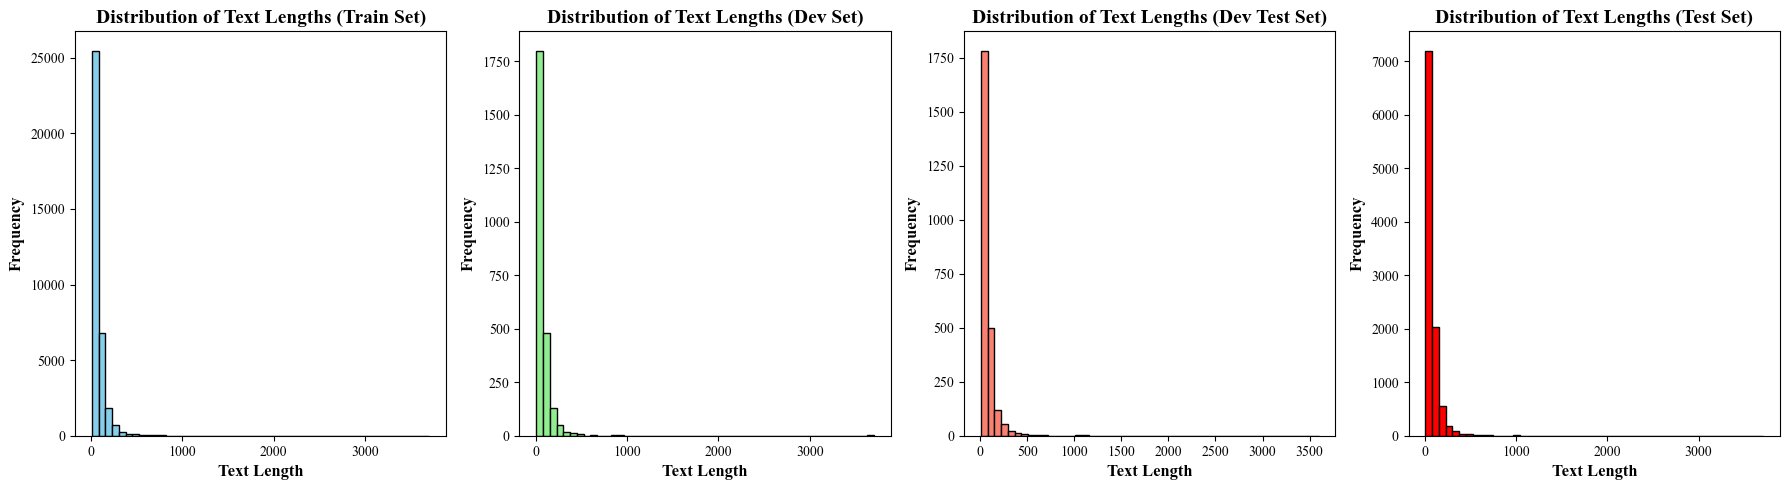

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font family to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

train_1A_df['text_length'] = train_1A_df['text'].apply(len)
dev_1A_df['text_length'] = dev_1A_df['text'].apply(len)
dev_test_1A_df['text_length'] = dev_test_1A_df['text'].apply(len)
test_1A_df['text_length'] = test_1A_df['text'].apply(len)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].hist(train_1A_df['text_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Text Lengths (Train Set)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Text Length', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)


axes[1].hist(dev_1A_df['text_length'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Text Lengths (Dev Set)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Text Length', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

axes[2].hist(dev_test_1A_df['text_length'], bins=50, color='salmon', edgecolor='black')
axes[2].set_title('Distribution of Text Lengths (Dev Test Set)', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Text Length', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[2].tick_params(axis='x', labelsize=10)
axes[2].tick_params(axis='y', labelsize=10)


axes[3].hist(test_1A_df['text_length'], bins=50, color='red', edgecolor='black')
axes[3].set_title('Distribution of Text Lengths (Test Set)', fontweight='bold', fontsize=14)
axes[3].set_xlabel('Text Length', fontweight='bold', fontsize=12)
axes[3].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[3].tick_params(axis='x', labelsize=10)
axes[3].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

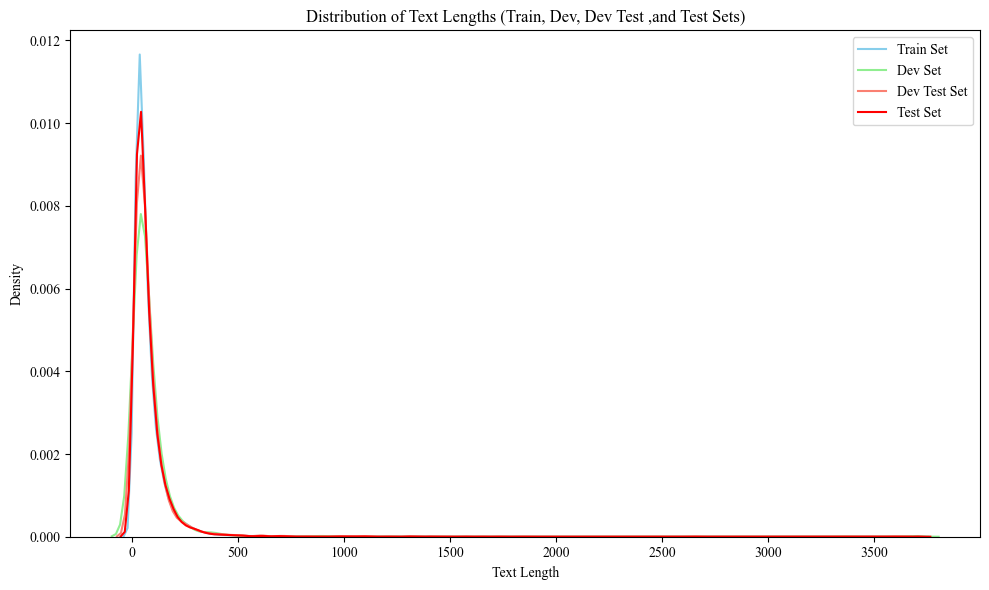

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

train_1A_df['text_length'] = train_1A_df['text'].apply(len)
dev_1A_df['text_length'] = dev_1A_df['text'].apply(len)
dev_test_1A_df['text_length'] = dev_test_1A_df['text'].apply(len)
test_1A_df['text_length'] = test_1A_df['text'].apply(len)

plt.figure(figsize=(10, 6))

sns.kdeplot(train_1A_df['text_length'], color='skyblue', label='Train Set', ax=plt.gca())
sns.kdeplot(dev_1A_df['text_length'], color='lightgreen', label='Dev Set', ax=plt.gca())
sns.kdeplot(dev_test_1A_df['text_length'], color='salmon', label='Dev Test Set', ax=plt.gca())
sns.kdeplot(test_1A_df['text_length'], color='red', label='Test Set', ax=plt.gca())

plt.title('Distribution of Text Lengths (Train, Dev, Dev Test ,and Test Sets)')
plt.xlabel('Text Length')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Task 1A

### Examine data types and structure


In [ ]:
print("Info for train_1A_df:")
train_1A_df.info()

print("\nInfo for dev_1A_df:")
dev_1A_df.info()

print("\nInfo for dev_test_1A_df:")
dev_test_1A_df.info()

print("\nInfo for test_1A_df:")
test_1A_df.info()

Info for train_1A_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35522 entries, 0 to 35521
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           35522 non-null  int64 
 1   text         35522 non-null  object
 2   label        35522 non-null  object
 3   text_length  35522 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.1+ MB

Info for dev_1A_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           2512 non-null   int64 
 1   text         2512 non-null   object
 2   label        2512 non-null   object
 3   text_length  2512 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 78.6+ KB

Info for dev_test_1A_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 4 columns):
 #   Column       

### Check if there is any null value

In [ ]:
print("Null values in train_1A_df:")
print(train_1A_df.isnull().sum())

print("\nNull values in dev_1A_df:")
print(dev_1A_df.isnull().sum())

print("\nNull values in dev_test_1A_df:")
print(dev_test_1A_df.isnull().sum())

print("\nNull values in test_1A_df:")
print(test_1A_df.isnull().sum())

Null values in train_1A_df:
id             0
text           0
label          0
text_length    0
dtype: int64

Null values in dev_1A_df:
id             0
text           0
label          0
text_length    0
dtype: int64

Null values in dev_test_1A_df:
id             0
text           0
label          0
text_length    0
dtype: int64

Null values in test_1A_df:
id             0
text           0
label          0
text_length    0
dtype: int64


### Explore unique values

In [ ]:
print("Number of unique IDs in train_1A_df:\t", train_1A_df['id'].nunique())
print("Number of unique IDs in dev_1A_df:\t", dev_1A_df['id'].nunique())
print("Number of unique IDs in dev_test_1A_df:\t", dev_test_1A_df['id'].nunique())
print("Number of unique IDs in test_1A_df:\t", test_1A_df['id'].nunique())

print("\nUnique labels in train_1A_df:\t", sorted(train_1A_df['label'].unique()))
print("Unique labels in dev_1A_df:\t", sorted(dev_1A_df['label'].unique()))
print("Unique labels in dev_test_1A_df:", sorted(dev_test_1A_df['label'].unique()))
print("Unique labels in test_1A_df:\t", sorted(test_1A_df['label'].unique()))

Number of unique IDs in train_1A_df:	 35522
Number of unique IDs in dev_1A_df:	 2512
Number of unique IDs in dev_test_1A_df:	 2512
Number of unique IDs in test_1A_df:	 10200

Unique labels in train_1A_df:	 ['Abusive', 'None', 'Political Hate', 'Profane', 'Religious Hate', 'Sexism']
Unique labels in dev_1A_df:	 ['Abusive', 'None', 'Political Hate', 'Profane', 'Religious Hate', 'Sexism']
Unique labels in dev_test_1A_df: ['Abusive', 'None', 'Political Hate', 'Profane', 'Religious Hate', 'Sexism']
Unique labels in test_1A_df:	 ['Abusive', 'None', 'Political Hate', 'Profane', 'Religious Hate', 'Sexism']


### Analyze Label Distribution

Number of examples per label (Train Set):
 label
None              19954
Abusive            8212
Political Hate     4227
Profane            2331
Religious Hate      676
Sexism              122
Name: count, dtype: int64

Number of examples per label (Dev Set):
 label
None              1451
Abusive            564
Political Hate     291
Profane            157
Religious Hate      38
Sexism              11
Name: count, dtype: int64

Number of examples per label (Dev Test Set):
 label
None              1447
Abusive            549
Political Hate     283
Profane            185
Religious Hate      40
Sexism               8
Name: count, dtype: int64

Number of examples per label (Test Set):
 label
None              5751
Abusive           2312
Political Hate    1220
Profane            709
Religious Hate     179
Sexism              29
Name: count, dtype: int64


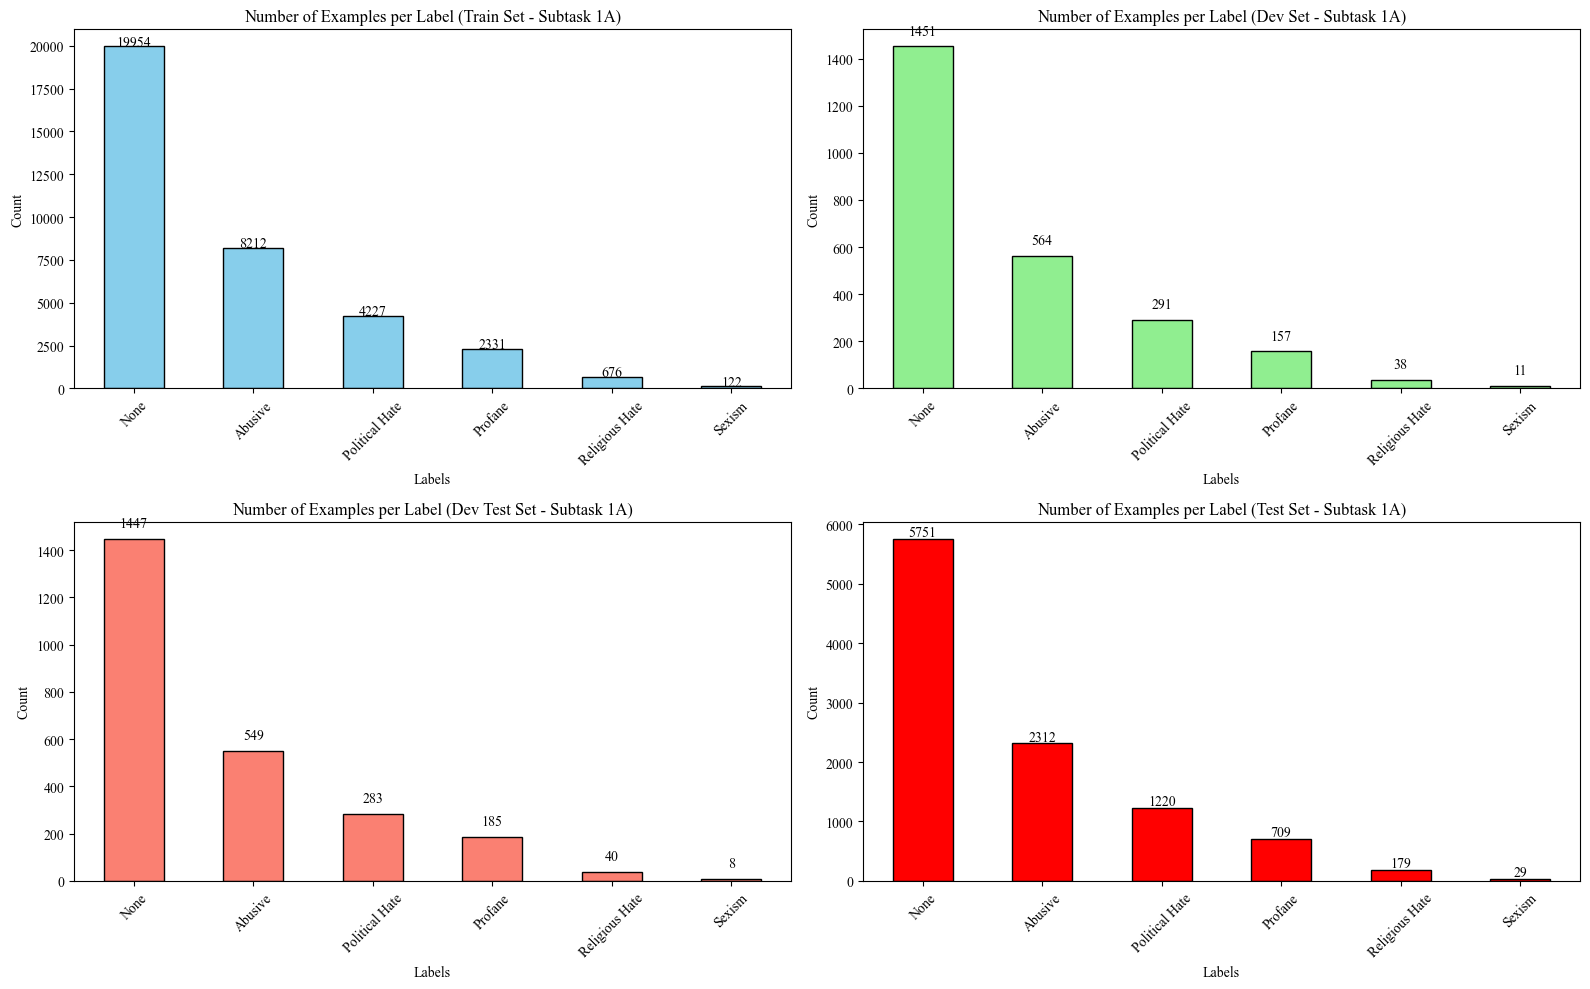

In [ ]:
import matplotlib.pyplot as plt

# Count labels for train set (including 'None')
train_label_counts = train_1A_df['label'].value_counts()
print("Number of examples per label (Train Set):\n", train_label_counts)

# Count labels for dev set (including 'None')
dev_label_counts = dev_1A_df['label'].value_counts()
print("\nNumber of examples per label (Dev Set):\n", dev_label_counts)

# Count labels for dev_test set (including 'None')
dev_test_label_counts = dev_test_1A_df['label'].value_counts()
print("\nNumber of examples per label (Dev Test Set):\n", dev_test_label_counts)

# Count labels for test set (including 'None')
test_label_counts = test_1A_df['label'].value_counts()
print("\nNumber of examples per label (Test Set):\n", test_label_counts)


# Create subplots for side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot bar chart for train set on the first subplot
train_label_counts.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Number of Examples per Label (Train Set - Subtask 1A)")
axes[0, 0].set_xlabel("Labels")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for train set
for i, count in enumerate(train_label_counts):
    axes[0, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev set on the second subplot
dev_label_counts.plot(kind="bar", color="lightgreen", edgecolor="black", ax=axes[0, 1])
axes[0, 1].set_title("Number of Examples per Label (Dev Set - Subtask 1A)")
axes[0, 1].set_xlabel("Labels")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev set
for i, count in enumerate(dev_label_counts):
    axes[0, 1].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev_test set on the third subplot
dev_test_label_counts.plot(kind="bar", color="salmon", edgecolor="black", ax=axes[1, 0])
axes[1, 0].set_title("Number of Examples per Label (Dev Test Set - Subtask 1A)")
axes[1, 0].set_xlabel("Labels")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev_test set
for i, count in enumerate(dev_test_label_counts):
    axes[1, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for test set on the fourth subplot
test_label_counts.plot(kind="bar", color="red", edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("Number of Examples per Label (Test Set - Subtask 1A)")
axes[1, 1].set_xlabel("Labels")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for test set
for i, count in enumerate(test_label_counts):
    axes[1, 1].text(i, count + 50, str(count), ha='center', fontsize=10)


plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 label
None              56.173639
Abusive           23.118068
Political Hate    11.899668
Profane            6.562131
Religious Hate     1.903046
Sexism             0.343449
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 label
None              57.762739
Abusive           22.452229
Political Hate    11.584395
Profane            6.250000
Religious Hate     1.512739
Sexism             0.437898
Name: proportion, dtype: float64

Percentage of examples per label (Dev Test Set):
 label
None              57.603503
Abusive           21.855096
Political Hate    11.265924
Profane            7.364650
Religious Hate     1.592357
Sexism             0.318471
Name: proportion, dtype: float64

Percentage of examples per label (Test Set):
 label
None              56.382353
Abusive           22.666667
Political Hate    11.960784
Profane            6.950980
Religious Hate     1.754902
Sexism             0.284314
Name: proporti

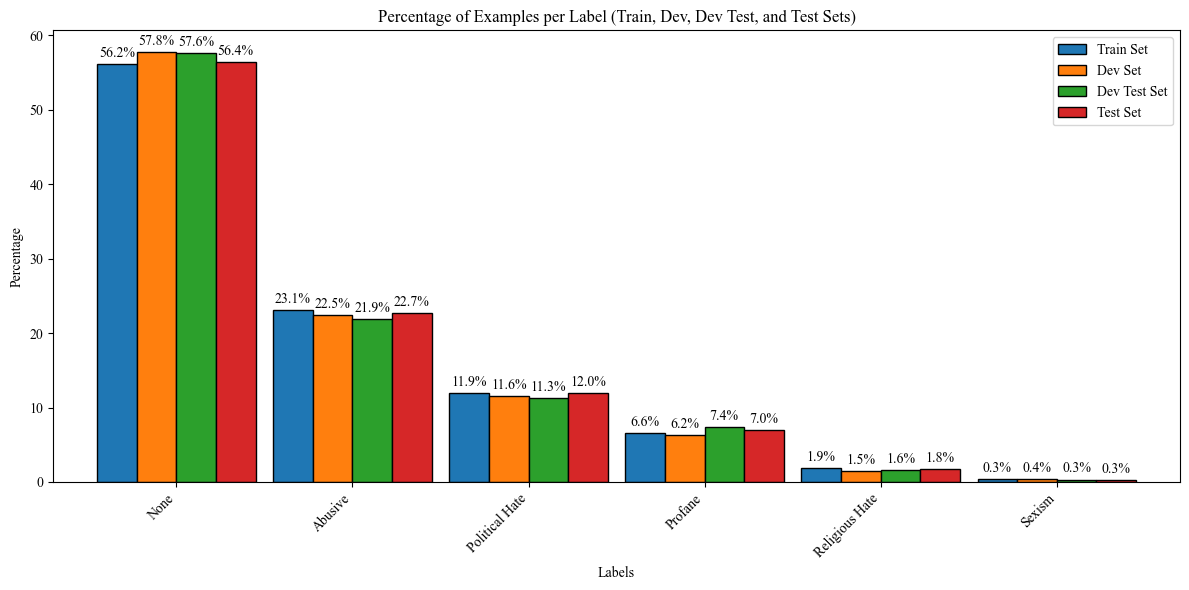

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate percentage of labels for train set
train_label_percentages = train_1A_df['label'].value_counts(normalize=True)*100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1A_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Calculate percentage of labels for dev_test set
dev_test_label_percentages = dev_test_1A_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Dev Test Set):\n", dev_test_label_percentages)

# Calculate percentage of labels for test set
test_label_percentages = test_1A_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Test Set):\n", test_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages,
    'Dev Test Set': dev_test_label_percentages,
    'Test Set': test_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)


ax = combined_percentages.plot(kind='bar', figsize=(12, 6), edgecolor='black', width=0.9)

plt.title('Percentage of Examples per Label (Train, Dev, Dev Test, and Test Sets)')
plt.xlabel('Labels')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)


plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 label
None              56.173639
Abusive           23.118068
Political Hate    11.899668
Profane            6.562131
Religious Hate     1.903046
Sexism             0.343449
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 label
None              57.762739
Abusive           22.452229
Political Hate    11.584395
Profane            6.250000
Religious Hate     1.512739
Sexism             0.437898
Name: proportion, dtype: float64

Percentage of examples per label (Test Set):
 label
None              56.382353
Abusive           22.666667
Political Hate    11.960784
Profane            6.950980
Religious Hate     1.754902
Sexism             0.284314
Name: proportion, dtype: float64


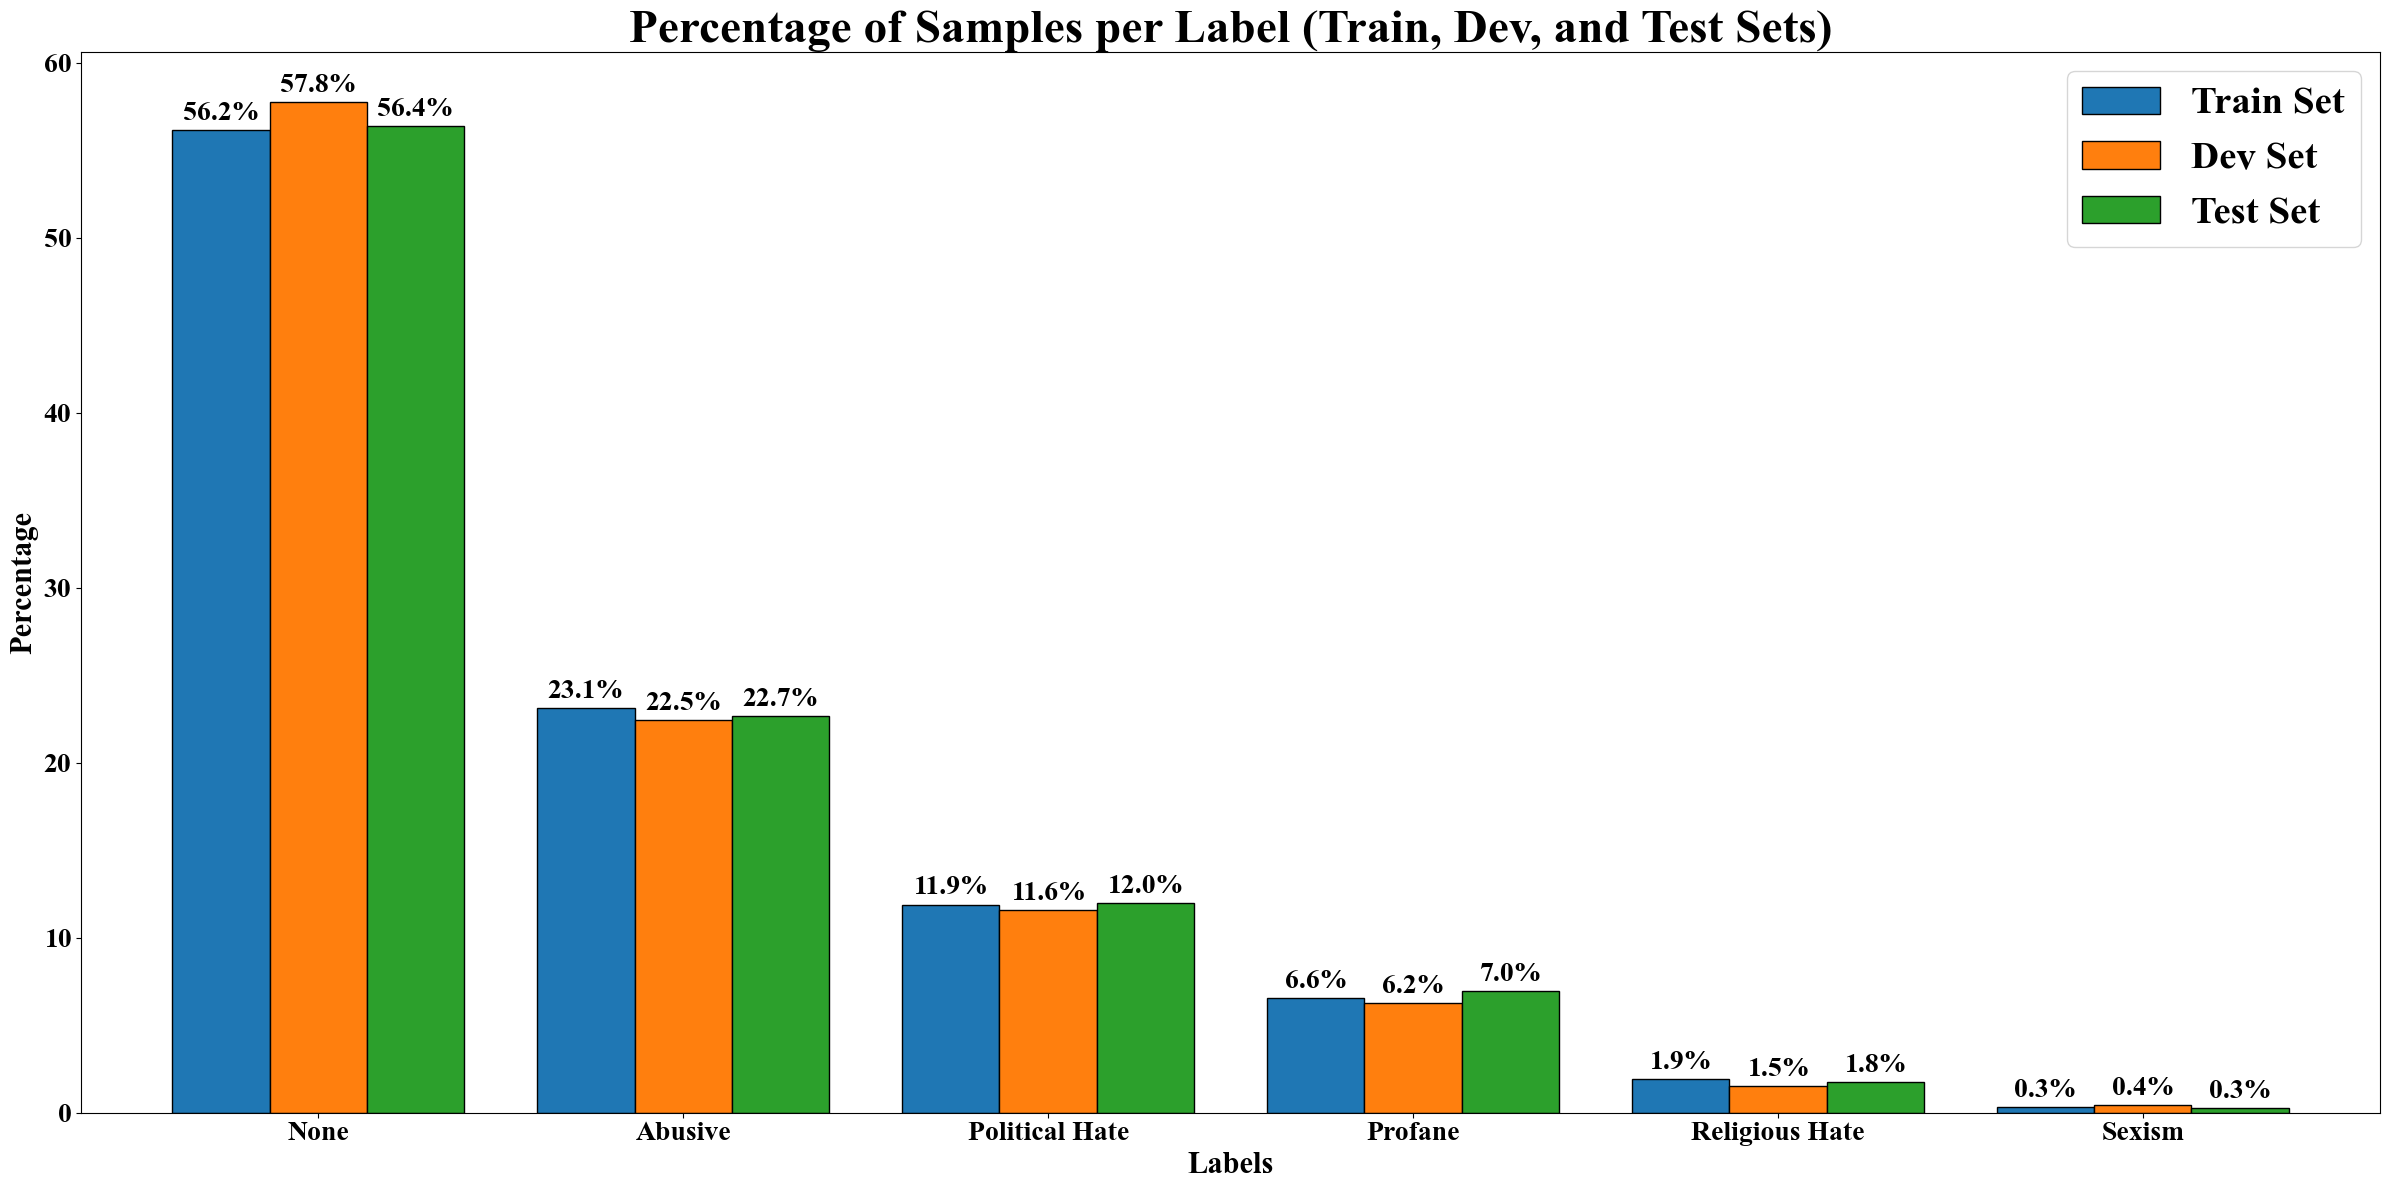

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set font family to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Calculate percentage of labels for train set
train_label_percentages = train_1A_df['label'].value_counts(normalize=True)*100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1A_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Calculate percentage of labels for test set
test_label_percentages = test_1A_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Test Set):\n", test_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages,
    'Test Set': test_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)

ax = combined_percentages.plot(kind='bar', figsize=(24, 12), edgecolor='black', width=0.8)

plt.title('Percentage of Samples per Label (Train, Dev, and Test Sets)', fontweight='bold', fontsize=34)
plt.xlabel('Labels', fontweight='bold', fontsize=22)
plt.ylabel('Percentage', fontweight='bold', fontsize=22)
plt.xticks(rotation=0, ha='center', fontweight='bold', fontsize=20) # Rotate labels for better readability
plt.yticks(fontweight='bold', fontsize=20)

# Make legend font bigger and bold
legend = plt.legend(fontsize=28)
for text in legend.get_texts():
    text.set_fontweight('bold')

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontweight='bold', fontsize=20)


plt.tight_layout()
plt.show()

## Task 1B

### Examine data types and structure


In [ ]:
print("Info for train_1B_df:")
train_1B_df.info()

print("\nInfo for dev_1B_df:")
dev_1B_df.info()

print("\nInfo for dev_test_1B_df:")
dev_test_1B_df.info()

print("\nInfo for test_1B_df:")
test_1B_df.info()

Info for train_1B_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35522 entries, 0 to 35521
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      35522 non-null  int64 
 1   text    35522 non-null  object
 2   label   35522 non-null  object
dtypes: int64(1), object(2)
memory usage: 832.7+ KB

Info for dev_1B_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2512 non-null   int64 
 1   text    2512 non-null   object
 2   label   2512 non-null   object
dtypes: int64(1), object(2)
memory usage: 59.0+ KB

Info for dev_test_1B_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2512 non-null   int64 
 1   text    2512 non-null   object
 2  

### Check if there is any null value

In [ ]:
print("Null values in train_1B_df:")
print(train_1B_df.isnull().sum())

print("\nNull values in dev_1B_df:")
print(dev_1B_df.isnull().sum())

print("\nNull values in dev_test_1B_df:")
print(dev_test_1B_df.isnull().sum())

print("\nNull values in test_1B_df:")
print(test_1B_df.isnull().sum())

Null values in train_1B_df:
id       0
text     0
label    0
dtype: int64

Null values in dev_1B_df:
id       0
text     0
label    0
dtype: int64

Null values in dev_test_1B_df:
id       0
text     0
label    0
dtype: int64

Null values in test_1B_df:
id       0
text     0
label    0
dtype: int64


### Explore unique values

In [ ]:
print("Number of unique IDs in train_1B_df:", train_1B_df['id'].nunique())
print("Number of unique IDs in dev_1B_df:", dev_1B_df['id'].nunique())
print("Number of unique IDs in dev_test_1B_df:", dev_test_1B_df['id'].nunique())
print("Number of unique IDs in test_1B_df:", test_1B_df['id'].nunique())

print("\nUnique labels in train_1B_df:", sorted(train_1B_df['label'].unique()))
print("Unique labels in dev_1B_df:", sorted(dev_1B_df['label'].unique()))
print("Unique labels in dev_test_1B_df:", sorted(dev_test_1B_df['label'].unique()))
print("Unique labels in test_1B_df:", sorted(test_1B_df['label'].unique()))

Number of unique IDs in train_1B_df: 35522
Number of unique IDs in dev_1B_df: 2512
Number of unique IDs in dev_test_1B_df: 2512
Number of unique IDs in test_1B_df: 10200

Unique labels in train_1B_df: ['Community', 'Individual', 'None', 'Organization', 'Society']
Unique labels in dev_1B_df: ['Community', 'Individual', 'None', 'Organization', 'Society']
Unique labels in dev_test_1B_df: ['Community', 'Individual', 'None', 'Organization', 'Society']
Unique labels in test_1B_df: ['Community', 'Individual', 'None', 'Organization', 'Society']


### Analyze Label Distribution

Number of examples per label (Train Set):
 label
None            21190
Individual       5646
Organization     3846
Community        2635
Society          2205
Name: count, dtype: int64

Number of examples per label (Dev Set):
 label
None            1536
Individual       364
Organization     292
Community        179
Society          141
Name: count, dtype: int64

Number of examples per label (Dev Test Set):
 label
None            1528
Individual       391
Organization     292
Community        159
Society          142
Name: count, dtype: int64

Number of examples per label (Test Set):
 label
None            6093
Individual      1571
Organization    1152
Community        759
Society          625
Name: count, dtype: int64


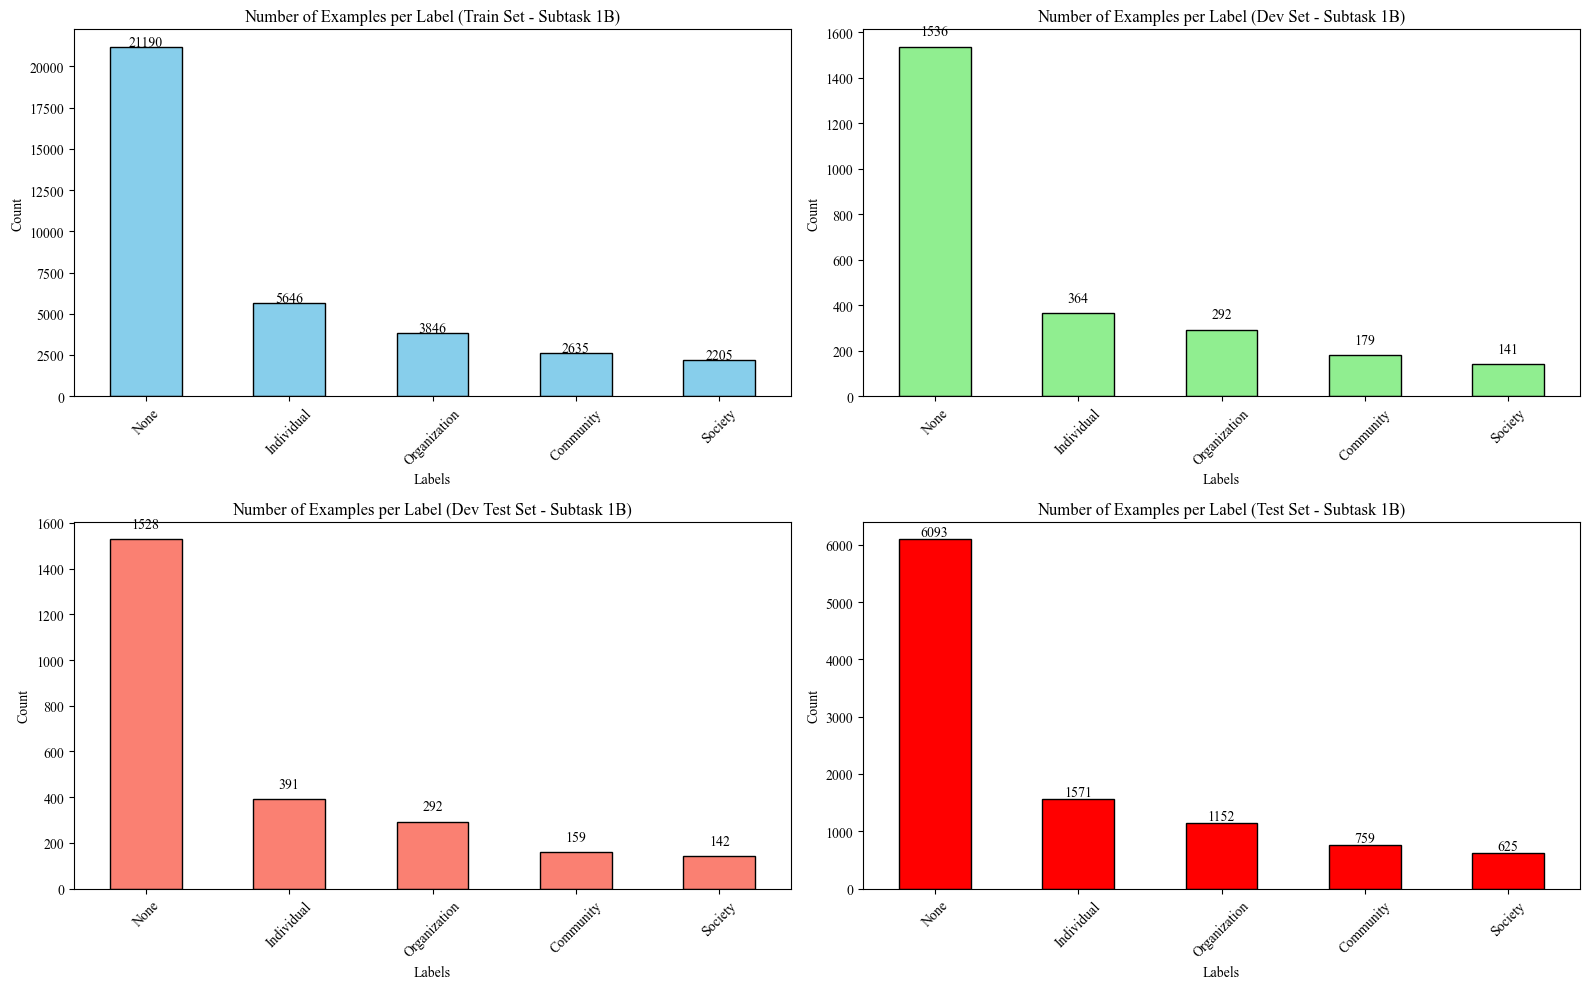

In [ ]:
import matplotlib.pyplot as plt

# Count labels for train set (including 'None')
train_label_counts = train_1B_df['label'].value_counts()
print("Number of examples per label (Train Set):\n", train_label_counts)

# Count labels for dev set (including 'None')
dev_label_counts = dev_1B_df['label'].value_counts()
print("\nNumber of examples per label (Dev Set):\n", dev_label_counts)

# Count labels for dev_test set (including 'None')
dev_test_label_counts = dev_test_1B_df['label'].value_counts()
print("\nNumber of examples per label (Dev Test Set):\n", dev_test_label_counts)

# Count labels for test set (including 'None')
test_label_counts = test_1B_df['label'].value_counts()
print("\nNumber of examples per label (Test Set):\n", test_label_counts)

# Create subplots for side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot bar chart for train set on the first subplot
train_label_counts.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Number of Examples per Label (Train Set - Subtask 1B)")
axes[0, 0].set_xlabel("Labels")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for train set
for i, count in enumerate(train_label_counts):
    axes[0, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev set on the second subplot
dev_label_counts.plot(kind="bar", color="lightgreen", edgecolor="black", ax=axes[0, 1])
axes[0, 1].set_title("Number of Examples per Label (Dev Set - Subtask 1B)")
axes[0, 1].set_xlabel("Labels")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev set
for i, count in enumerate(dev_label_counts):
    axes[0, 1].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev_test set on the third subplot
dev_test_label_counts.plot(kind="bar", color="salmon", edgecolor="black", ax=axes[1, 0])
axes[1, 0].set_title("Number of Examples per Label (Dev Test Set - Subtask 1B)")
axes[1, 0].set_xlabel("Labels")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev_test set
for i, count in enumerate(dev_test_label_counts):
    axes[1, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for test set on the fourth subplot
test_label_counts.plot(kind="bar", color="red", edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("Number of Examples per Label (Test Set - Subtask 1B)")
axes[1, 1].set_xlabel("Labels")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for test set
for i, count in enumerate(test_label_counts):
    axes[1, 1].text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 label
None            59.653173
Individual      15.894375
Organization    10.827093
Community        7.417938
Society          6.207421
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 label
None            61.146497
Individual      14.490446
Organization    11.624204
Community        7.125796
Society          5.613057
Name: proportion, dtype: float64


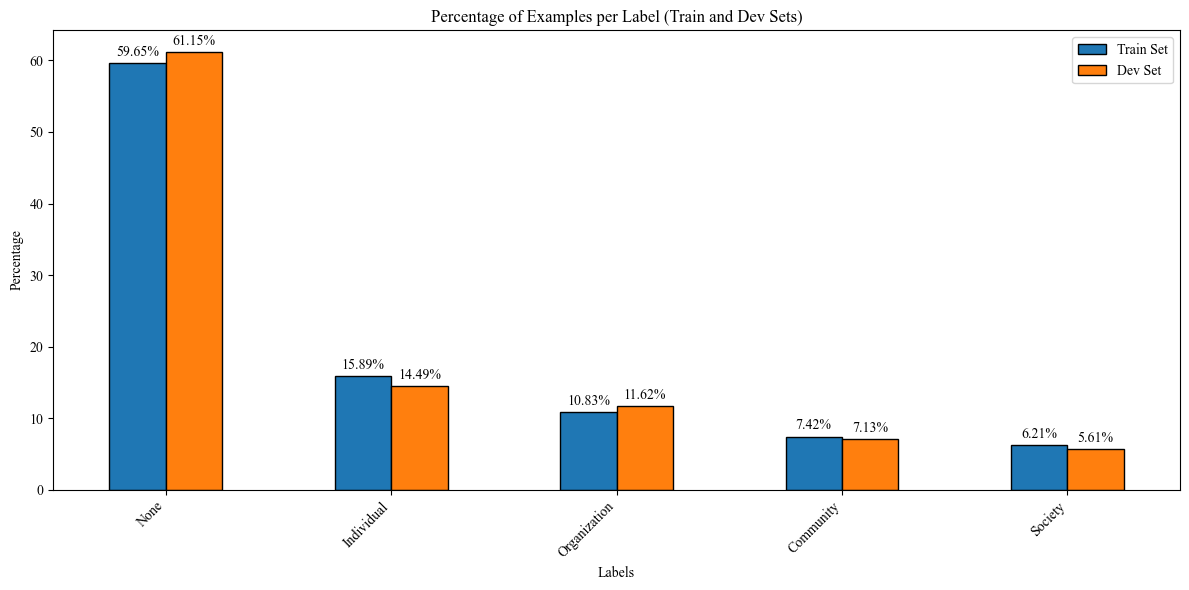

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate percentage of labels for train set
train_label_percentages = train_1B_df['label'].value_counts(normalize=True) * 100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1B_df['label'].value_counts(normalize=True) * 100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)


ax = combined_percentages.plot(kind='bar', figsize=(12, 6), edgecolor='black')

plt.title('Percentage of Examples per Label (Train and Dev Sets)')
plt.xlabel('Labels')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)


plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 label
None            59.653173
Individual      15.894375
Organization    10.827093
Community        7.417938
Society          6.207421
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 label
None            61.146497
Individual      14.490446
Organization    11.624204
Community        7.125796
Society          5.613057
Name: proportion, dtype: float64

Percentage of examples per label (Test Set):
 label
None            59.735294
Individual      15.401961
Organization    11.294118
Community        7.441176
Society          6.127451
Name: proportion, dtype: float64


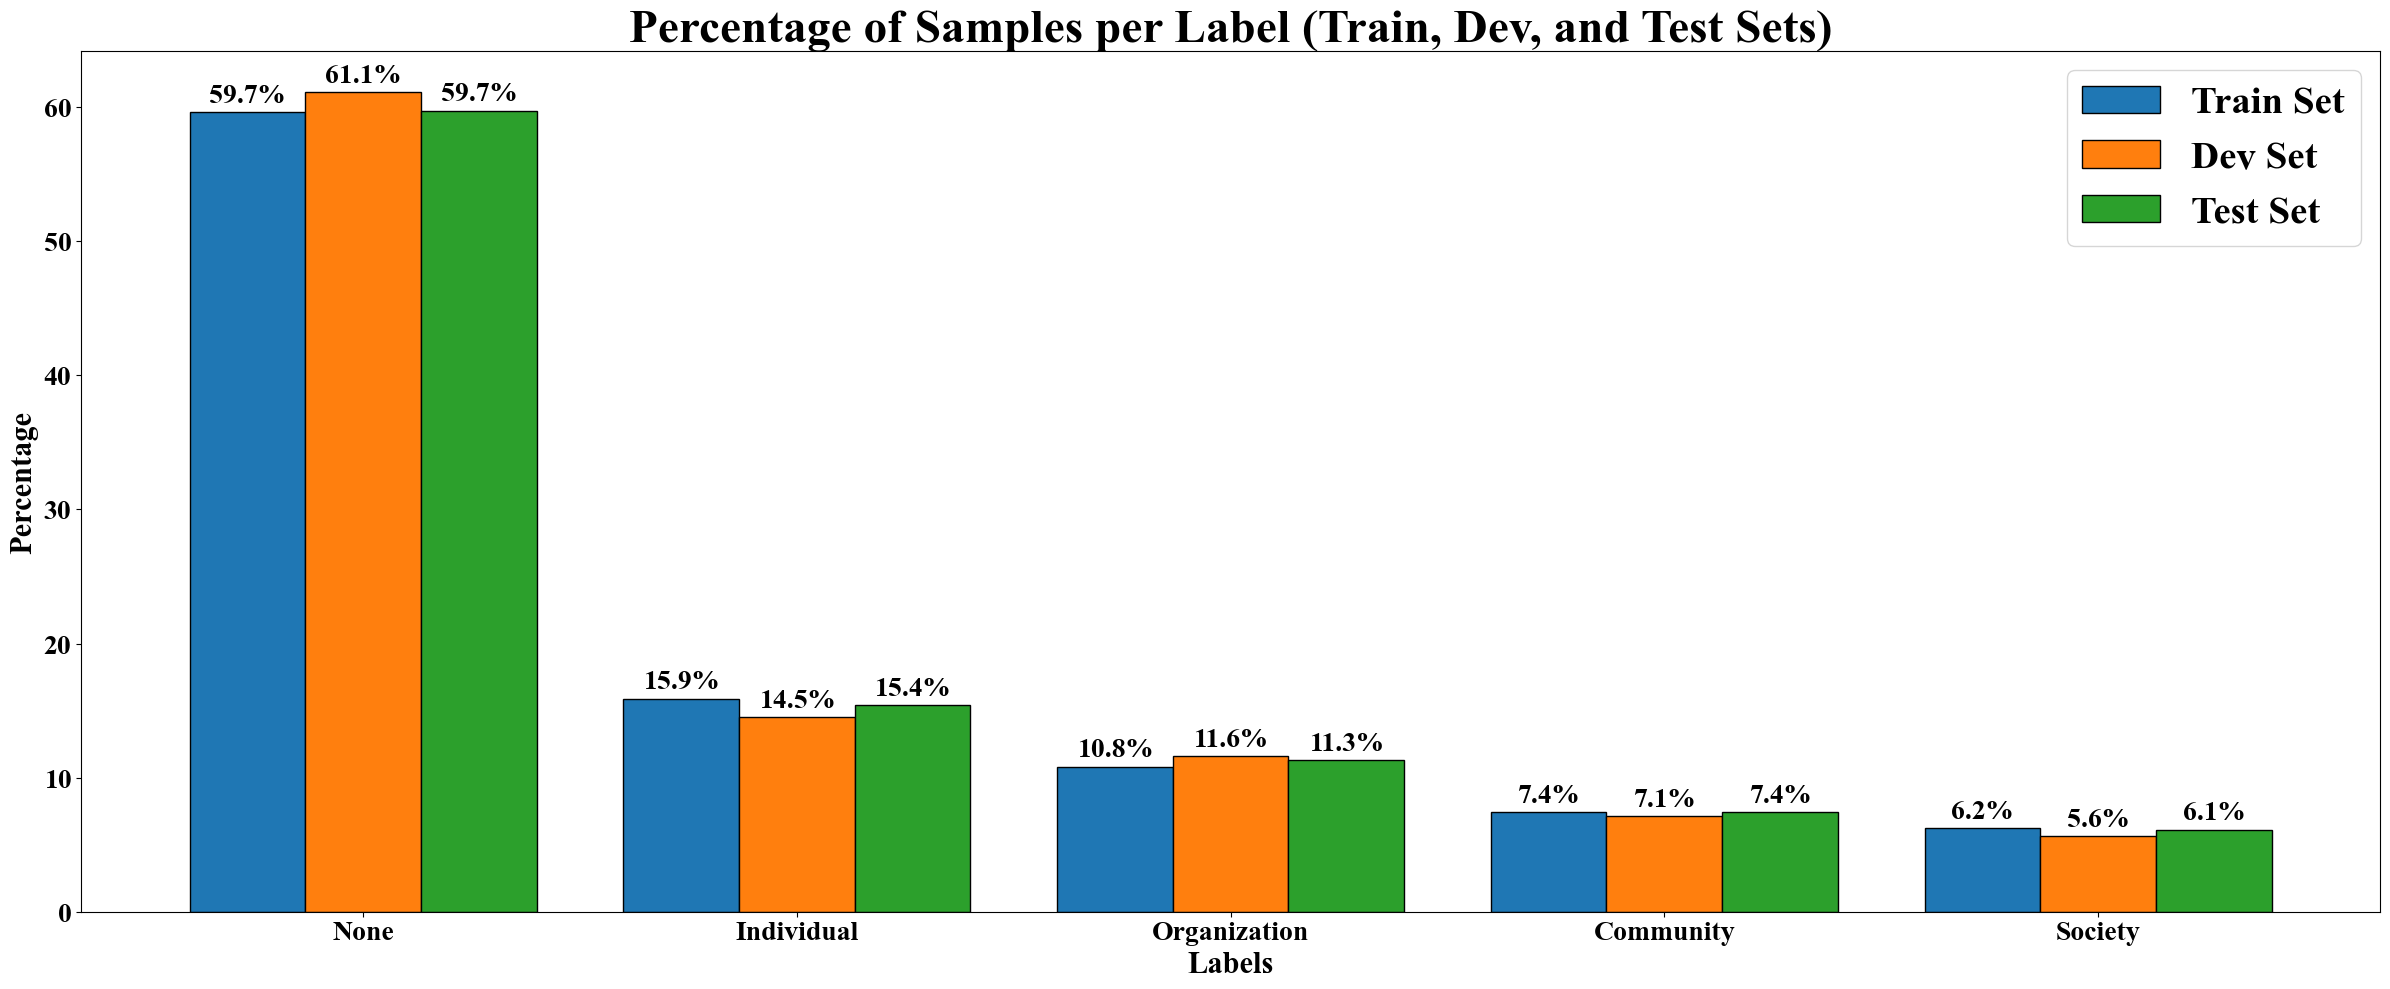

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set font family to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Calculate percentage of labels for train set
train_label_percentages = train_1B_df['label'].value_counts(normalize=True)*100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1B_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Calculate percentage of labels for test set
test_label_percentages = test_1B_df['label'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Test Set):\n", test_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages,
    'Test Set': test_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)

ax = combined_percentages.plot(kind='bar', figsize=(24, 10), edgecolor='black', width=0.8)

plt.title('Percentage of Samples per Label (Train, Dev, and Test Sets)', fontweight='bold', fontsize=34)
plt.xlabel('Labels', fontweight='bold', fontsize=22)
plt.ylabel('Percentage', fontweight='bold', fontsize=22)
plt.xticks(rotation=0, ha='center', fontweight='bold', fontsize=20) # Rotate labels for better readability
plt.yticks(fontweight='bold', fontsize=20)

# Make legend font bigger and bold
legend = plt.legend(fontsize=28)
for text in legend.get_texts():
    text.set_fontweight('bold')

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontweight='bold', fontsize=20)


plt.tight_layout()
plt.show()

## Task 1C

### Examine data types and structure


In [ ]:
print("Info for train_1C_df:")
train_1C_df.info()

print("\nInfo for dev_1C_df:")
dev_1C_df.info()

print("\nInfo for dev_test_1C_df:")
dev_test_1C_df.info()

print("\nInfo for test_1C_df:")
test_1C_df.info()

Info for train_1C_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35522 entries, 0 to 35521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             35522 non-null  int64 
 1   text           35522 non-null  object
 2   hate_type      35522 non-null  object
 3   hate_severity  35522 non-null  object
 4   to_whom        35522 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.4+ MB

Info for dev_1C_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             2512 non-null   int64 
 1   text           2512 non-null   object
 2   hate_type      2512 non-null   object
 3   hate_severity  2512 non-null   object
 4   to_whom        2512 non-null   object
dtypes: int64(1), object(4)
memory usage: 98.3+ KB

Info for dev_test_1C_df:
<class 'pandas

### Check if there is any null value

In [ ]:
print("Null values in train_1C_df:")
print(train_1C_df.isnull().sum())

print("\nNull values in dev_1C_df:")
print(dev_1C_df.isnull().sum())

print("\nNull values in dev_test_1C_df:")
print(dev_test_1C_df.isnull().sum())

print("\nNull values in test_1C_df:")
print(test_1C_df.isnull().sum())

Null values in train_1C_df:
id               0
text             0
hate_type        0
hate_severity    0
to_whom          0
dtype: int64

Null values in dev_1C_df:
id               0
text             0
hate_type        0
hate_severity    0
to_whom          0
dtype: int64

Null values in dev_test_1C_df:
id               0
text             0
hate_type        0
hate_severity    0
to_whom          0
dtype: int64

Null values in test_1C_df:
id               0
text             0
hate_type        0
hate_severity    0
to_whom          0
dtype: int64


### Explore unique values

In [ ]:
print("Number of unique IDs in train_1C_df:", train_1C_df['id'].nunique())
print("Number of unique IDs in dev_1C_df:", dev_1C_df['id'].nunique())
print("Number of unique IDs in dev_test_1C_df:", dev_test_1C_df['id'].nunique())
print("Number of unique IDs in test_1C_df:", test_1C_df['id'].nunique())

print("\nUnique labels in train_1C_df:", sorted(train_1C_df['hate_severity'].unique()))
print("Unique labels in dev_1C_df:", sorted(dev_1C_df['hate_severity'].unique()))
print("Unique labels in dev_test_1C_df:", sorted(dev_test_1C_df['hate_severity'].unique()))
print("Unique labels in test_1C_df:", sorted(test_1C_df['hate_severity'].unique()))

Number of unique IDs in train_1C_df: 35522
Number of unique IDs in dev_1C_df: 2512
Number of unique IDs in dev_test_1C_df: 2512
Number of unique IDs in test_1C_df: 10200

Unique labels in train_1C_df: ['Little to None', 'Mild', 'Severe']
Unique labels in dev_1C_df: ['Little to None', 'Mild', 'Severe']
Unique labels in dev_test_1C_df: ['Little to None', 'Mild', 'Severe']
Unique labels in test_1C_df: ['Little to None', 'Mild', 'Severe']


### Analyze Label Distribution

Number of examples per label (Train Set):
 hate_severity
Little to None    23489
Mild               6853
Severe             5180
Name: count, dtype: int64

Number of examples per label (Dev Set):
 hate_severity
Little to None    1703
Mild               483
Severe             326
Name: count, dtype: int64

Number of examples per label (Dev Test Set):
 hate_severity
Little to None    1714
Mild               426
Severe             372
Name: count, dtype: int64

Number of examples per label (Test Set):
 hate_severity
Little to None    6737
Mild              2001
Severe            1462
Name: count, dtype: int64


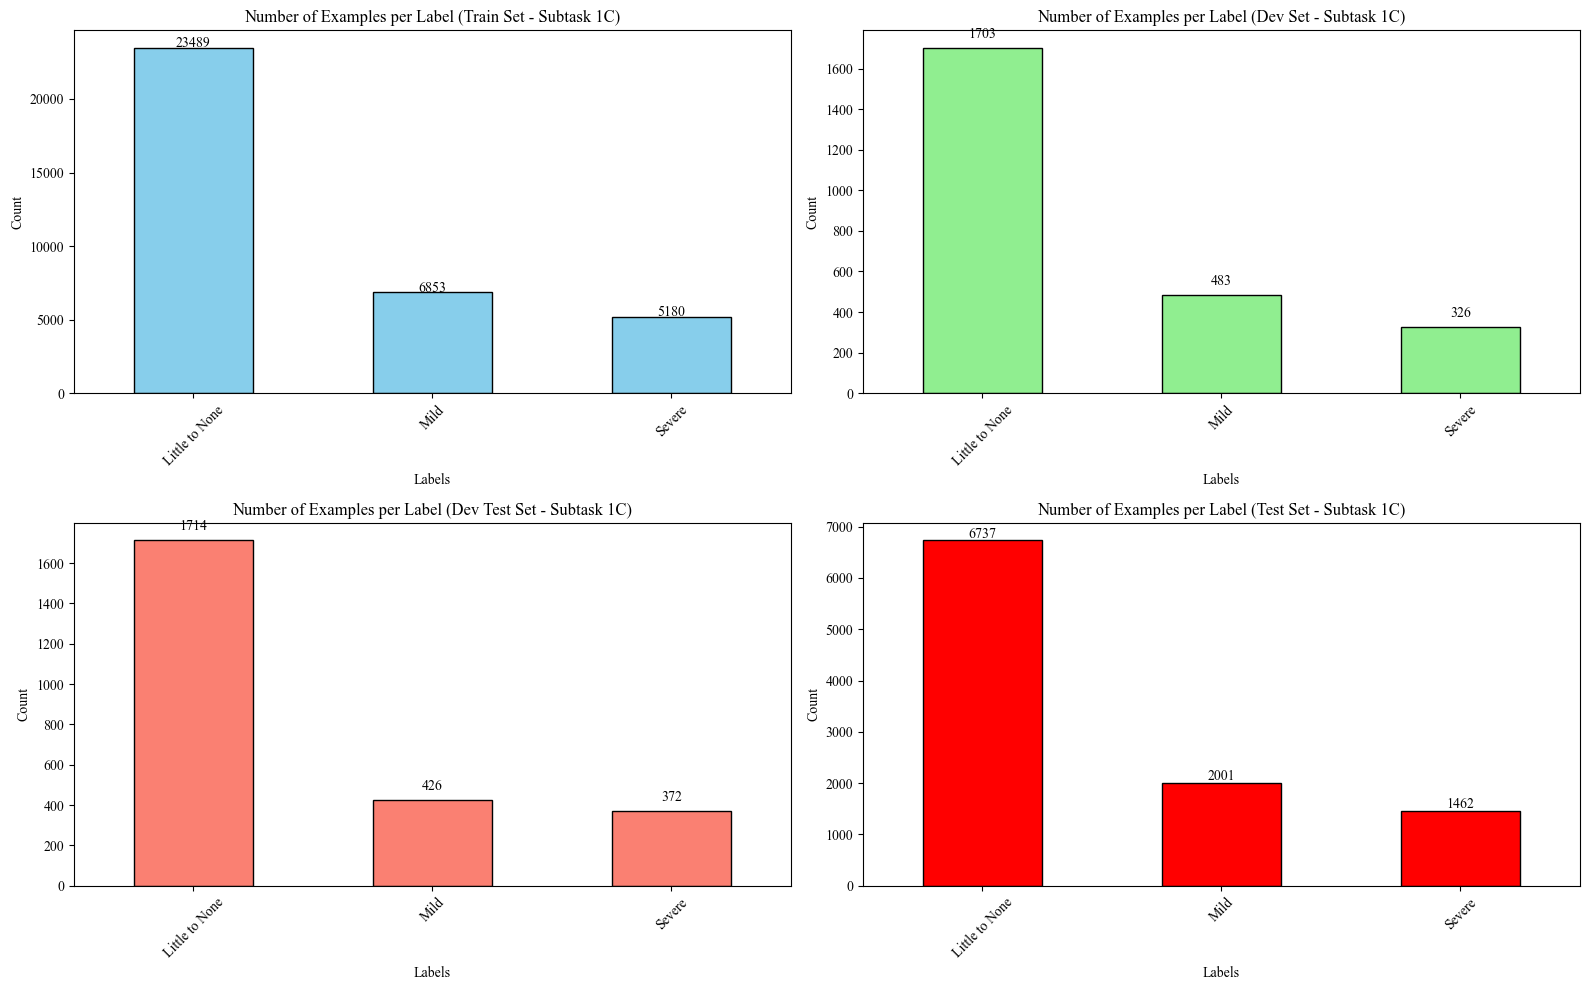

In [ ]:
import matplotlib.pyplot as plt

# Count labels for train set (including 'None')
train_label_counts = train_1C_df['hate_severity'].value_counts()
print("Number of examples per label (Train Set):\n", train_label_counts)

# Count labels for dev set (including 'None')
dev_label_counts = dev_1C_df['hate_severity'].value_counts()
print("\nNumber of examples per label (Dev Set):\n", dev_label_counts)

# Count labels for dev_test set (including 'None')
dev_test_label_counts = dev_test_1C_df['hate_severity'].value_counts()
print("\nNumber of examples per label (Dev Test Set):\n", dev_test_label_counts)

# Count labels for test set (including 'None')
test_label_counts = test_1C_df['hate_severity'].value_counts()
print("\nNumber of examples per label (Test Set):\n", test_label_counts)

# Create subplots for side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot bar chart for train set on the first subplot
train_label_counts.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Number of Examples per Label (Train Set - Subtask 1C)")
axes[0, 0].set_xlabel("Labels")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for train set
for i, count in enumerate(train_label_counts):
    axes[0, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev set on the second subplot
dev_label_counts.plot(kind="bar", color="lightgreen", edgecolor="black", ax=axes[0, 1])
axes[0, 1].set_title("Number of Examples per Label (Dev Set - Subtask 1C)")
axes[0, 1].set_xlabel("Labels")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev set
for i, count in enumerate(dev_label_counts):
    axes[0, 1].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for dev_test set on the third subplot
dev_test_label_counts.plot(kind="bar", color="salmon", edgecolor="black", ax=axes[1, 0])
axes[1, 0].set_title("Number of Examples per Label (Dev Test Set - Subtask 1C)")
axes[1, 0].set_xlabel("Labels")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis='x', rotation=45)

# Add counts on top of bars for dev_test set
for i, count in enumerate(dev_test_label_counts):
    axes[1, 0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Plot bar chart for test set on the fourth subplot
test_label_counts.plot(kind="bar", color="red", edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("Number of Examples per Label (Test Set - Subtask 1C)")
axes[1, 1].set_xlabel("Labels")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=45)

# Add counts on top of bars for test set
for i, count in enumerate(test_label_counts):
    axes[1, 1].text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 hate_severity
Little to None    66.125218
Mild              19.292270
Severe            14.582512
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 hate_severity
Little to None    67.794586
Mild              19.227707
Severe            12.977707
Name: proportion, dtype: float64


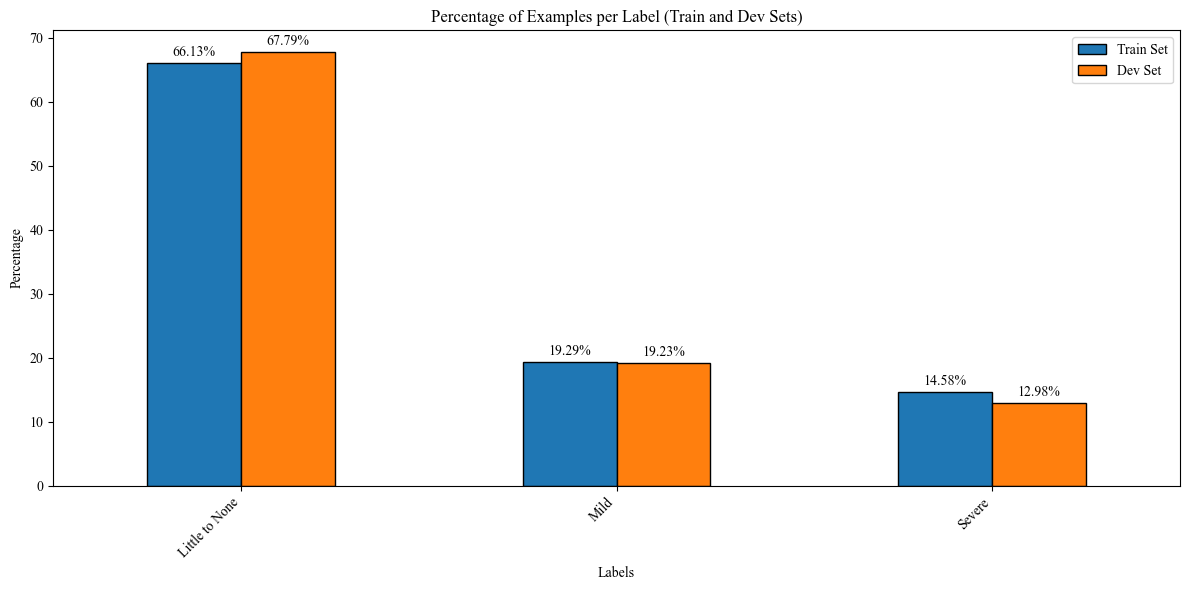

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate percentage of labels for train set
train_label_percentages = train_1C_df['hate_severity'].value_counts(normalize=True) * 100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1C_df['hate_severity'].value_counts(normalize=True) * 100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)


ax = combined_percentages.plot(kind='bar', figsize=(12, 6), edgecolor='black')

plt.title('Percentage of Examples per Label (Train and Dev Sets)')
plt.xlabel('Labels')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)


plt.tight_layout()
plt.show()

Percentage of examples per label (Train Set):
 hate_severity
Little to None    66.125218
Mild              19.292270
Severe            14.582512
Name: proportion, dtype: float64

Percentage of examples per label (Dev Set):
 hate_severity
Little to None    67.794586
Mild              19.227707
Severe            12.977707
Name: proportion, dtype: float64

Percentage of examples per label (Test Set):
 hate_severity
Little to None    66.049020
Mild              19.617647
Severe            14.333333
Name: proportion, dtype: float64


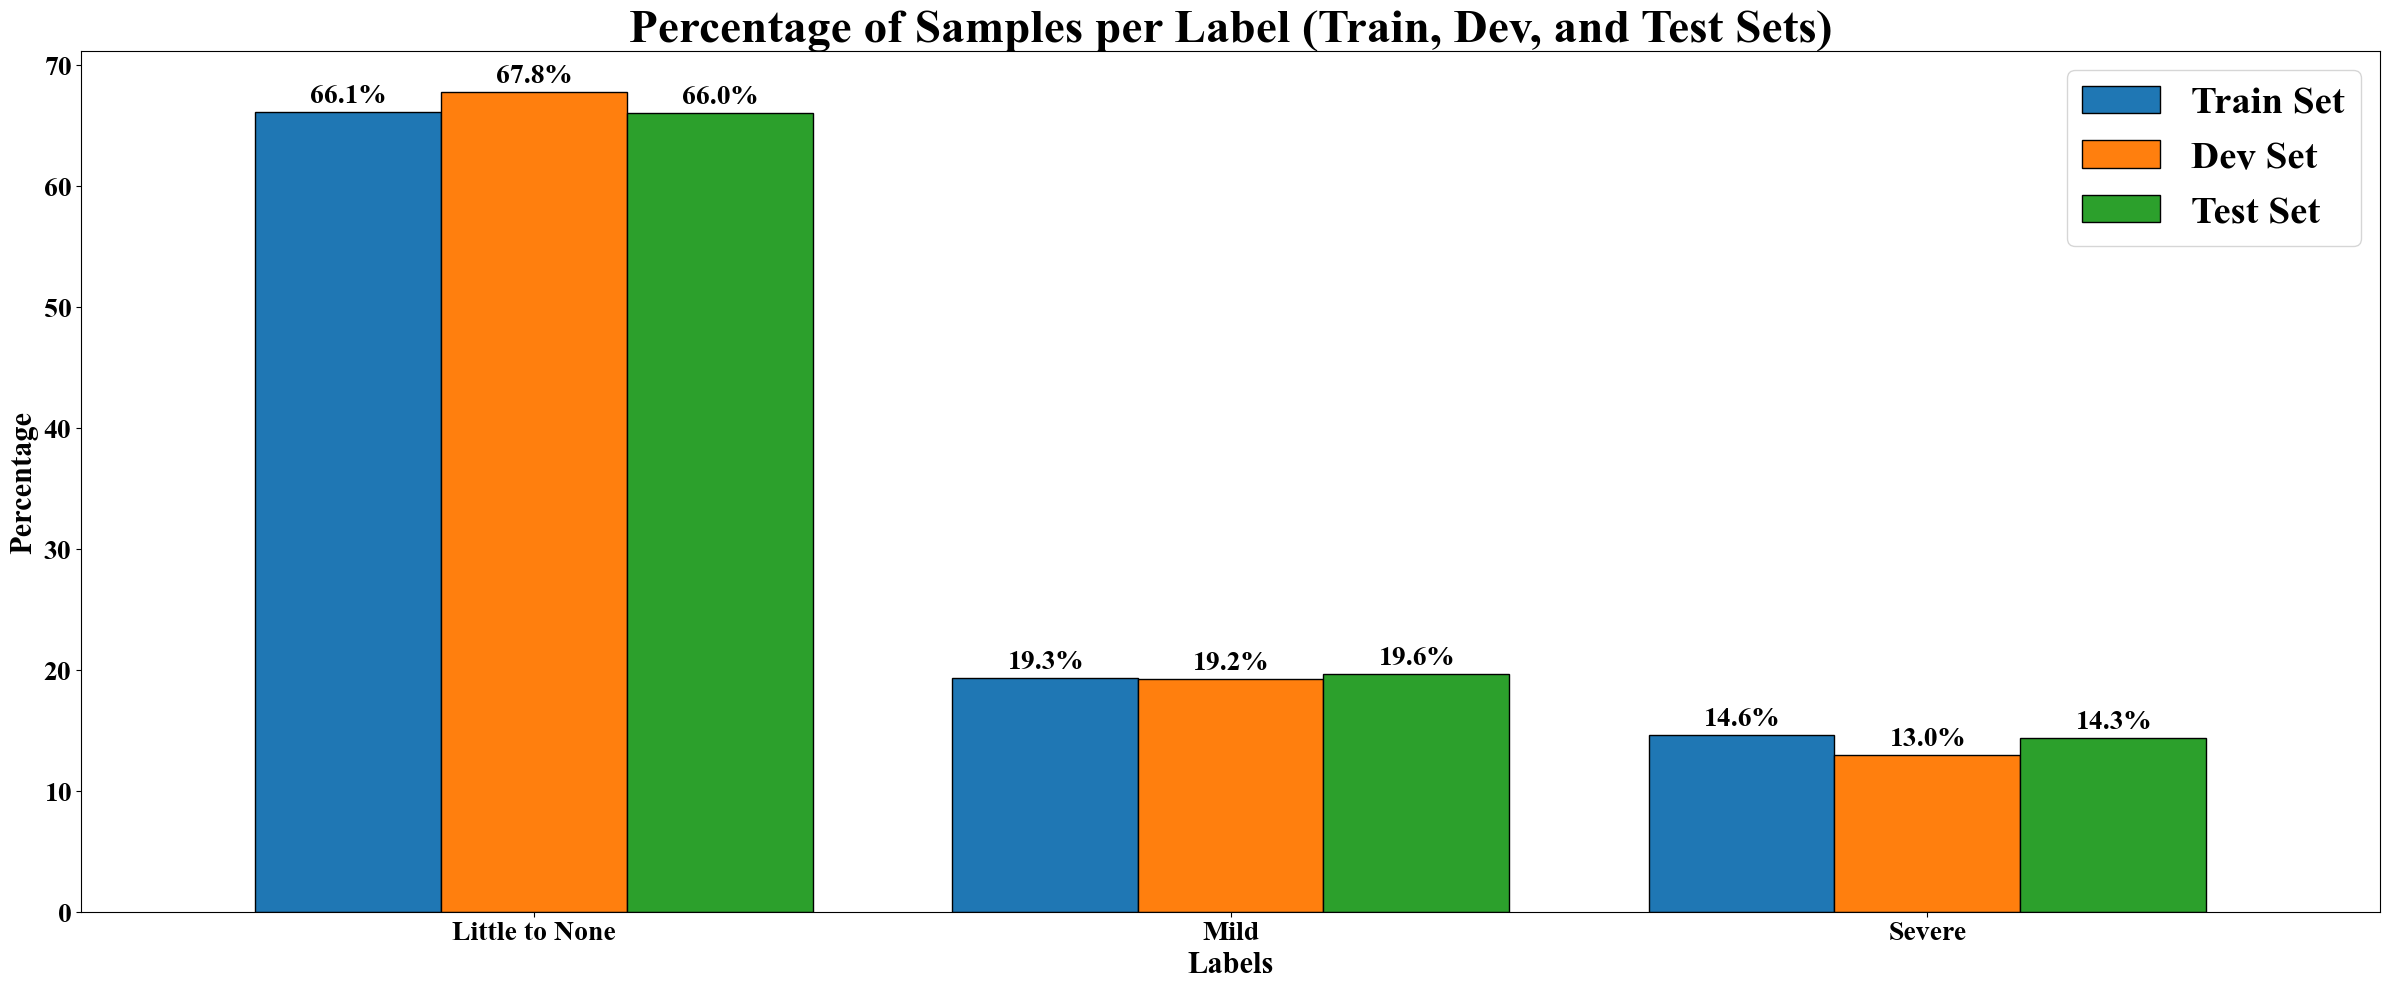

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set font family to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Calculate percentage of labels for train set
train_label_percentages = train_1C_df['hate_severity'].value_counts(normalize=True)*100
print("Percentage of examples per label (Train Set):\n", train_label_percentages)

# Calculate percentage of labels for dev set
dev_label_percentages = dev_1C_df['hate_severity'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Dev Set):\n", dev_label_percentages)

# Calculate percentage of labels for test set
test_label_percentages = test_1C_df['hate_severity'].value_counts(normalize=True)*100
print("\nPercentage of examples per label (Test Set):\n", test_label_percentages)

# Combine dataframes for easier plotting
combined_percentages = pd.DataFrame({
    'Train Set': train_label_percentages,
    'Dev Set': dev_label_percentages,
    'Test Set': test_label_percentages
}).fillna(0) # Fill any missing labels in one set with 0

# Sort the labels by percentage in the 'Train Set' in descending order
combined_percentages = combined_percentages.sort_values(by='Train Set', ascending=False)

ax = combined_percentages.plot(kind='bar', figsize=(24, 10), edgecolor='black', width=0.8)

plt.title('Percentage of Samples per Label (Train, Dev, and Test Sets)', fontweight='bold', fontsize=34)
plt.xlabel('Labels', fontweight='bold', fontsize=22)
plt.ylabel('Percentage', fontweight='bold', fontsize=22)
plt.xticks(rotation=0, ha='center', fontweight='bold', fontsize=20) # Rotate labels for better readability
plt.yticks(fontweight='bold', fontsize=20)

# Make legend font bigger and bold
legend = plt.legend(fontsize=28)
for text in legend.get_texts():
    text.set_fontweight('bold')

# Add percentages on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontweight='bold', fontsize=20)


plt.tight_layout()
plt.show()